In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd

In [ ]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1
        self.bxt_x = lambda x: 0
        self.bxt_xx = lambda x: 0
        self.sigmaxt_x = lambda x: 0
        self.sigmaxt_xx = lambda x: 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        result = np.zeros(self.Nx)
        for k in range(0, self.Nx):
            result[k] = x0[k] + np.random.normal(0, 1) * np.sqrt(t - t0)
        return result

    def PathGenerator(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = self.SampleFromDensity(x_data[i - 1], t_data[i], t_data[i - 1])
        return t_data, x_data

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + dwt[i - 1]
        return t_data, x_data

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data

    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + \
                        1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * (dwt[i - 1]**2 - dt)
        return t_data, x_data

    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1]) - 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])) * dt +\
                        self.sigmaxt(x_data[i - 1]) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1]) + 1/2 * self.bxt_x(x_data[i - 1]) * self.sigmaxt(x_data[i - 1]) +\
                        1/4 * self.sigmaxt(x_data[i - 1])**2 * self.sigmaxt_xx(x_data[i - 1])) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1]) * self.bxt_x(x_data[i - 1]) + 1/4 * self.bxt_xx(x_data[i - 1]) * self.sigmaxt(x_data[i - 1])**2) * dt**2
        return t_data, x_data

    def PredictorCorrectorSolution(self, dwt, eta = 1/2, alpha = 1/2):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            yw = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
            bwim1 = self.bxt(x_data[i - 1]) - eta * self.sigmaxt(x_data[i - 1]) * self.sigmaxt_x(x_data[i - 1])
            bwi = self.bxt(yw) - eta * self.sigmaxt(yw) * self.sigmaxt_x(yw)
            x_data[i] = x_data[i - 1] + alpha * bwi * dt + (1 - alpha) * bwim1 * dt +\
                        eta * self.sigmaxt(yw) * dwt[i - 1] + (1 - eta) * self.sigmaxt(x_data[i - 1]) * dwt[i - 1]
        return t_data, x_data


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]
        self.bxt_x = lambda x: -self.params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu
            v = sigma**2 / (2 * theta)
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            m = mu + (x0[j] - mu) * np.exp(-theta * (t - t0))
            v = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t - t0)))
            result[j] = np.random.normal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta = self.params[0]
        mu = self.params[1]
        sigma = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = mu + (x_data[0] - mu) * np.exp(-theta * t_data)
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += sigma * np.exp(theta * t_data[i - 1]) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta * t_data[i])
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))
        self.bxt_x = lambda x: - self.params[1]
        self.sigmaxt_x = lambda x: self.params[2] * 1 / (2 * np.sqrt(np.maximum(x, 0)))
        self.sigmaxt_xx = lambda x: -self.params[2] * 1 / (4 * np.maximum(x, 0)**(1/4))

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2)
            u = 0
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def SampleFromDensity(self, x0, t, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        result = np.zeros(self.Nx)

        for j in range(0, self.Nx):
            c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
            u = c * x0[j] * np.exp(-k * (t - t0))
            #v = c * x
            q = 2 * k * theta / sigma**2 - 1
            result[j] = ncx2.rvs(2 * q + 2, 2 * u) / (2 * c)
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        Ito_integral_sum = np.zeros(self.Nx)
        Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data) + theta1/theta2
        for i in range(1, self.Nt + 1):
            Ito_integral_sum += theta3 * np.exp(theta2 * t_data[i - 1]) * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]
            x_data[i] = Determinated_part[i] + Ito_integral_sum * np.exp(-theta2 * t_data[i])
        return t_data, x_data


class BSMprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2] or [r, sigma]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x
        self.bxt_x = lambda x: self.params[0]
        self.sigmaxt_x = lambda x: self.params[1]

    def DefaultInitState(self):
        return np.ones(self.Nx)

    def SampleFromDensity(self, x0, t, t0):
        r = self.params[0]
        sigma = self.params[1]

        result = np.zeros(self.Nx)

        m = (r - 1/2 * sigma**2) * (t - t0)
        v = sigma**2 * (t - t0)

        for j in range(0, self.Nx):
            result[j] = x0[j] * np.random.lognormal(m, np.sqrt(v))
        return result

    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        r = self.params[0]
        sigma = self.params[1]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * dwt[i - 1])
        return t_data, x_data

Еxercise  1. Suppose we have a   Brownian motion  defined by
 $$
 dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \text{ with } (\theta_1, \theta_2) = (2, 0.5).
 $$
Compare approximations
*   the Euler approximation algorithm;
*   the 1st Milstein scheme;
*   the 2nd Milstein scheme;
*   the predictor-corrector method  (set default $\alpha = \eta = 1/2$);
*   KPS method

with the exact solution on $[0,1]$, levels of discretization $N=1024$.


Упражнение 1. Предположим, что броуновское движение задано:
$$
dX_t = \theta_1 X_tdt + \theta_2X_tdW_t, \quad X_0 = 1, \quad (\theta_1, \theta_2) = (2, 0.5).
$$
Сравните численные схемы
* алгоритм приближения Эйлера;
* 1-я схема Мильштейна;
* 2-я схема Мильштейна;
* метод предиктора-корректора (по умолчанию $\alpha = \eta = 1/2$);
* метод KPS

с точным решением на интервале $[0,1]$, для $N=1024$ точек.

In [ ]:
T = 1
Nx = 1
Nt = 1024

x0 = 1
init_state = x0 * np.ones(Nx)

#theta = 2
#mu = 10
#sigma = 3.5
#params = [theta, mu, sigma]

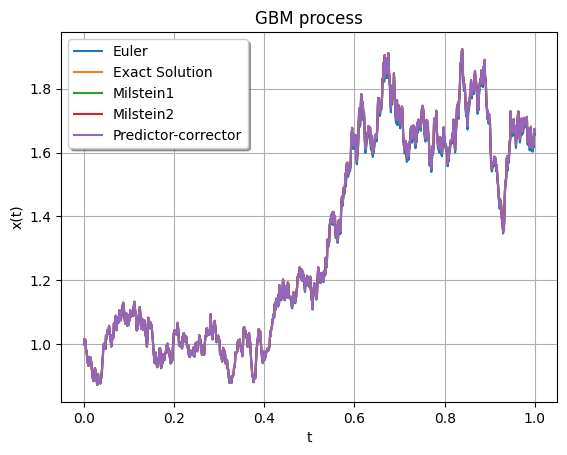

In [ ]:
theta1 = 1
theta2 = 1/2
params = [theta1, theta2]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)


BSMp = BSMprocess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = BSMp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = BSMp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = BSMp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = BSMp.PredictorCorrectorSolution(dwt, 1/2, 1/2)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("GBM process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the different approximations and the exact solution Brownian motion
for different levels of discretization
$$
N=\{2, 4, 8, 128, 256, 512, 1024, 8192, 16384, 32768\}
$$
being the number of subintervals of $[0,1]$.
As the result provide the table with maximum absolute difference.


In [ ]:
# your code

Task. Conduct a study of the influence of the choice of values $\alpha$ and $\eta$ ​​on the accuracy of the  solution and plot a 3D graph where the x-axis is $α$'s values, y-axis is $\eta$'s values, and z-axis are maximum absolute difference between the exact solution and the predictor-corrector approximation.



In [ ]:
# your code

Task 2.  Repeat the Task 1 for the Cox-Ingersoll-Ross process
$$
dX_t = (\theta_1 - \theta_2X_t)dt + \theta_3 \sqrt{ X_t}dW_t, X_0 = 10, (\theta_1, \theta_2, \theta_3) = (6, 3, 2).
$$

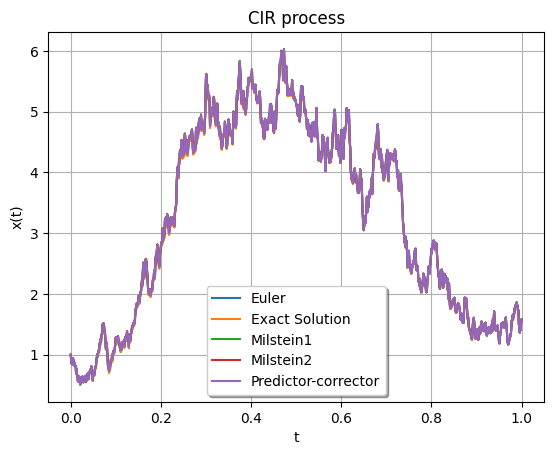

In [ ]:
theta1 = 6
theta2 = 3
theta3 = 2
params = [theta1, theta2, theta3]

dwt = np.random.normal(0, 1, size = (Nt, Nx)) * np.sqrt(T/Nt)

CIRp = CIRprocess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRp.EulerSolution(dwt)
plt.plot(t_data, x_data, label = 'Euler')

t_data, x_data = CIRp.ExactSolution(dwt)
plt.plot(t_data, x_data, label = 'Exact Solution')

t_data, x_data = CIRp.Milstein1Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein1')

t_data, x_data = CIRp.Milstein2Solution(dwt)
plt.plot(t_data, x_data, label = 'Milstein2')

t_data, x_data = CIRp.PredictorCorrectorSolution(dwt, 0.4, 0.6)
plt.plot(t_data, x_data, label = 'Predictor-corrector')

plt.title("CIR process")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Task. Compare the speed of convergence for four schemes from Task 1 with extract solution on the graph where the x-axis is  log(N) values, y-axis is  X(t). See example in the study aid.

In [ ]:
# your code

Task 3. Generate 100 paths using conditional distribution of
* Ornstein-Uhlenbeck process $θ = (1, 1, 0.5)$,
* Geometric Brownian motion process $θ = (0.3, 0.1)$,
* Cox-Ingersoll-Ross process $θ = (0.4, 0.3, 0.2)$

with $X_0=0.5$.
Plot the random path for each process.

In [ ]:
Nx = 1
Nt = 300

T = 1

params_BSM = [1.0, 2.0]
params_CIR = [0.5, 0.2, 1.0]
params_OU  = [1.0, 0.5, 1.5]

init_state = 0.5 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)
BSMp = BSMprocess(params_BSM, T, Nx, Nt, init_state)
CIRp = CIRprocess(params_CIR, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.PathGenerator()
t_data, x_data_BSM = BSMp.PathGenerator()
t_data, x_data_CIR = CIRp.PathGenerator()

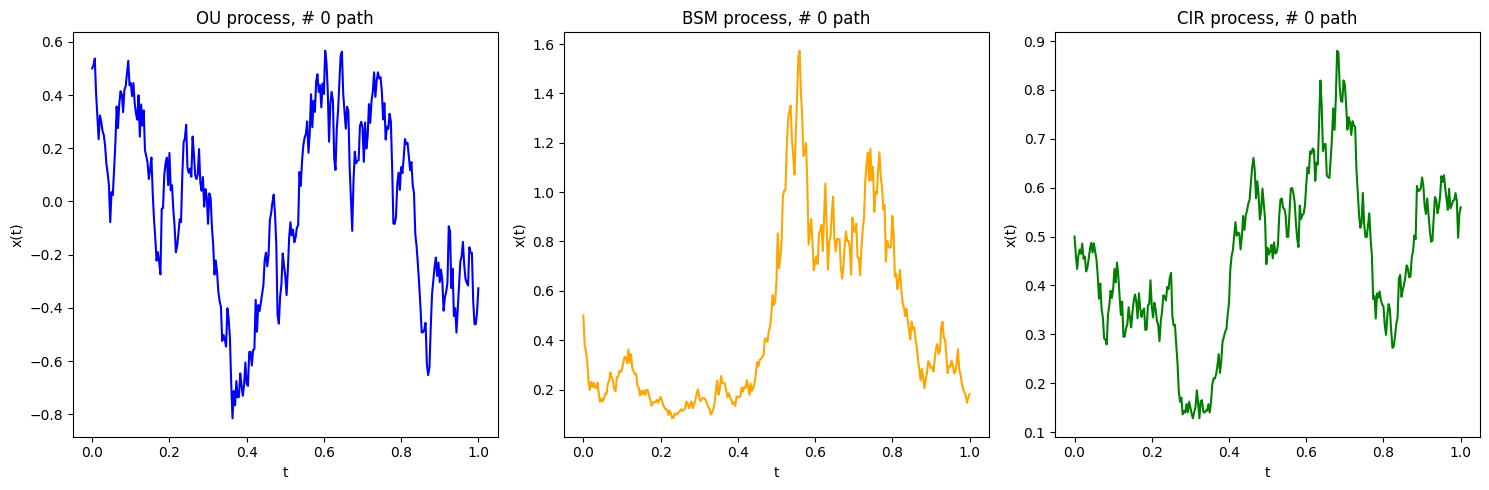

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

n = np.random.randint(0, Nx)

axs[0].plot(t_data, x_data_OU[:,n], color='blue')
axs[0].set_title(f'OU process, # {n} path')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x(t)')

axs[1].plot(t_data, x_data_BSM[:,n], color='orange')
axs[1].set_title(f'BSM process, # {n} path')
axs[1].set_xlabel('t')
axs[1].set_ylabel('x(t)')

axs[2].plot(t_data, x_data_CIR[:,n], color='green')
axs[2].set_title(f'CIR process, # {n} path')
axs[2].set_xlabel('t')
axs[2].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

In [ ]:
# save 100 paths to files

pd.DataFrame(data = x_data_OU, index = t_data).to_csv("OUprocess.csv")

pd.DataFrame(data = x_data_BSM, index = t_data).to_csv("BSMprocess.csv")

pd.DataFrame(data = x_data_CIR, index = t_data).to_csv("CIRprocess.csv")

Task. Using the class template from Task 1, create class and design the path generator for one from the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

In [ ]:
# your code

Task 4. For the processes from previous task plot
* cumulative distribution (cdf),
* density function (pdf),      
* calculate the 90\%-quantile.

In [ ]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(len(x))/float(len(x))
    return x, y

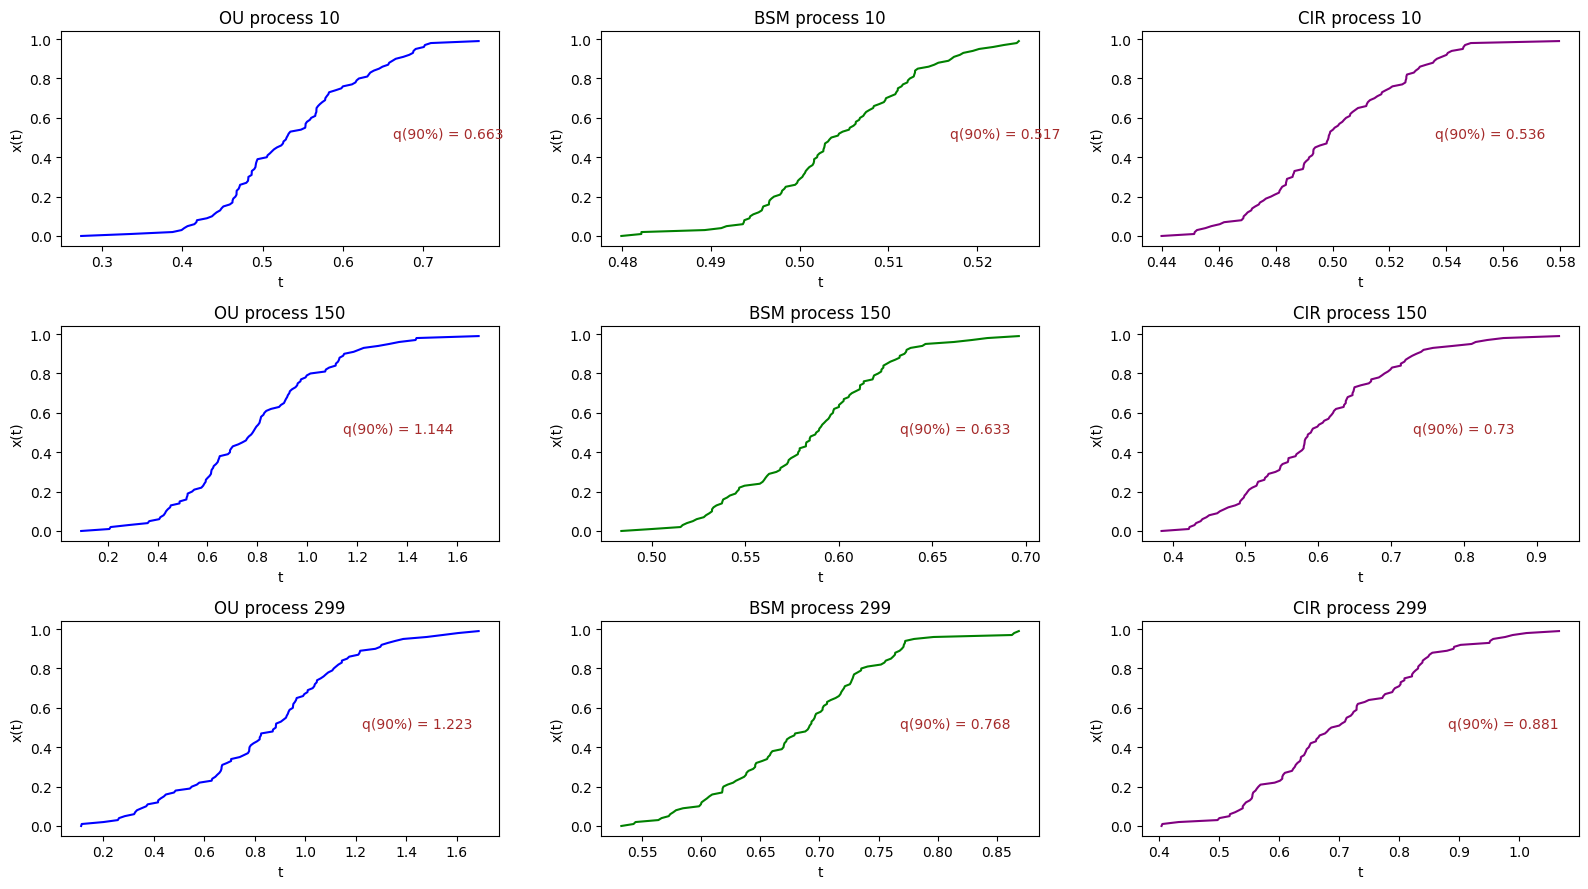

In [ ]:
#cdf function and 90% quantile

#distributions become more widely and change with time

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[0][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[1][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_BSM[n]), color='green')
axs[2][1].set_title(f'BSM process {n}')
val = round(np.quantile(x_data_BSM[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][2].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][2].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][2].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 3):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()
plt.show()

Task. Perform the Kolmogorov-Smirnov test for two samples and present your conclusions. Add vertical lines (90\%-quantile) into plots.
Resize the range on the X-axis so that all curves for one process have the same range.    

In [ ]:
# your code

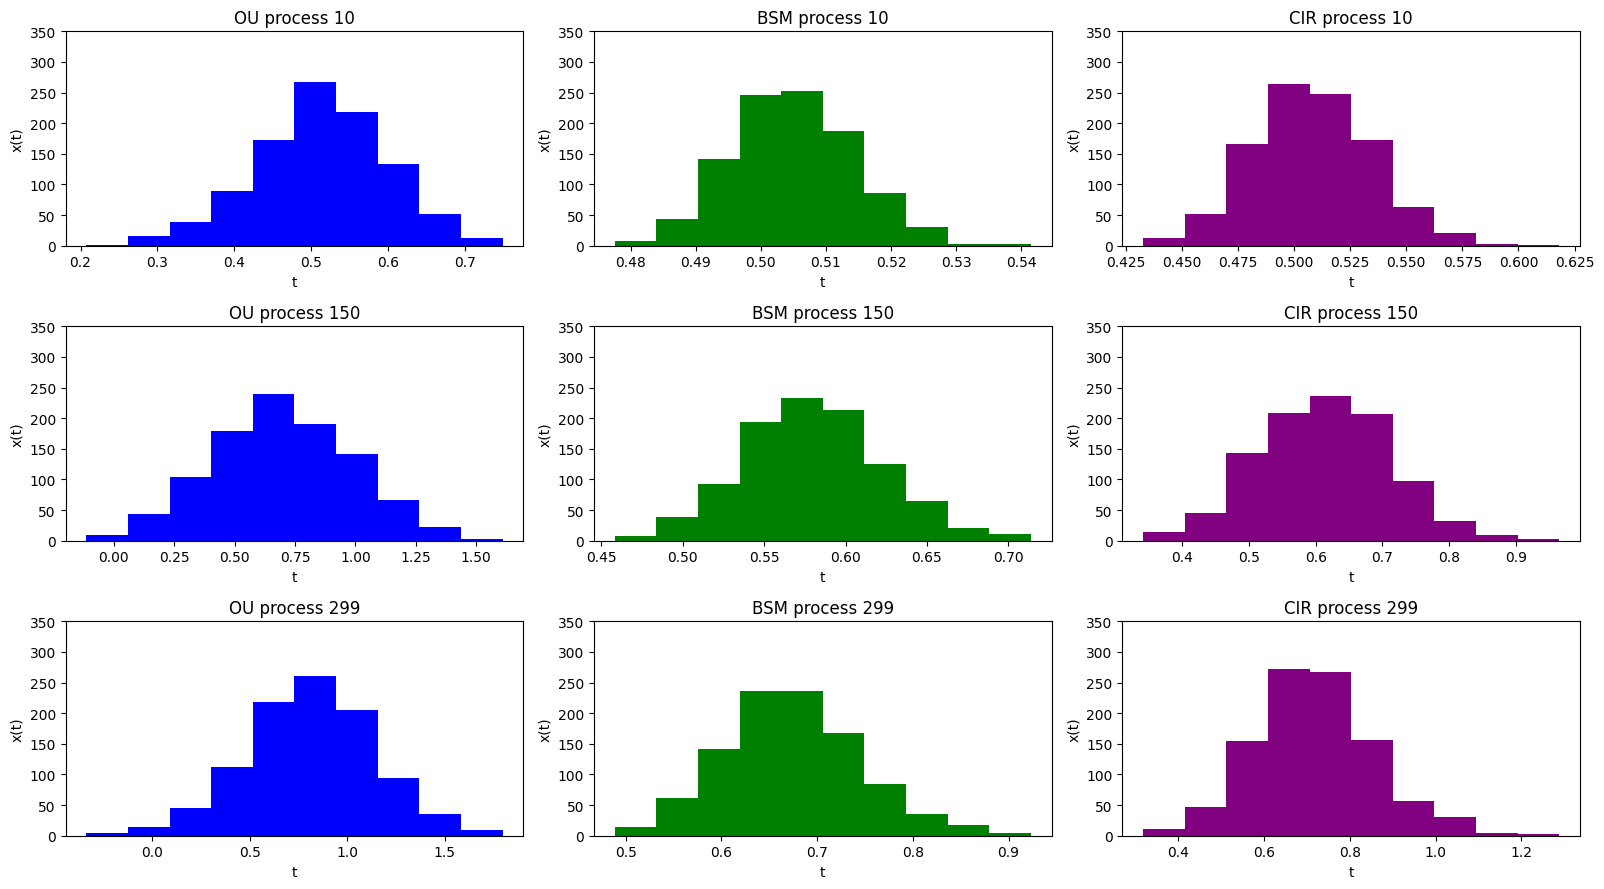

In [ ]:
#density function

fig, axs = plt.subplots(3, 3, figsize=(16, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_BSM[n], color='green')
axs[0][1].set_title(f'BSM process {n}')

axs[0][2].hist(x_data_CIR[n], color='purple')
axs[0][2].set_title(f'CIR process {n}')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process {n}')

axs[1][1].hist(x_data_BSM[n], color='green')
axs[1][1].set_title(f'BSM process {n}')

axs[1][2].hist(x_data_CIR[n], color='purple')
axs[1][2].set_title(f'CIR process {n}')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process {n}')

axs[2][1].hist(x_data_BSM[n], color='green')
axs[2][1].set_title(f'BSM process {n}')

axs[2][2].hist(x_data_CIR[n], color='purple')
axs[2][2].set_title(f'CIR process {n}')

for k in range(0, 3):
    for j in range(0, 3):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

Task. Perform a normality test on the histograms and present your conclusions.

Task 5.

In [ ]:
#to get stationary state we set initial state to be stationary
#generate 1000 trajectories using conditional distribution
#BSM doesnt have stationary state

#Distribution properties do not change as expected for stationary state

Nx = 1000
Nt = 300

T = 1

params_OU = [1, 1, 0.5]
paramsCIR = [0.4, 0.3, 0.2]


OUp = OUprocess(params_OU, T, Nx, Nt)
OUp.init_state = OUp.StationaryState()

CIRp = CIRprocess(params_OU, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()

t_data, x_data_OU = OUp.PathGenerator()

t_data, x_data_CIR = CIRp.PathGenerator()

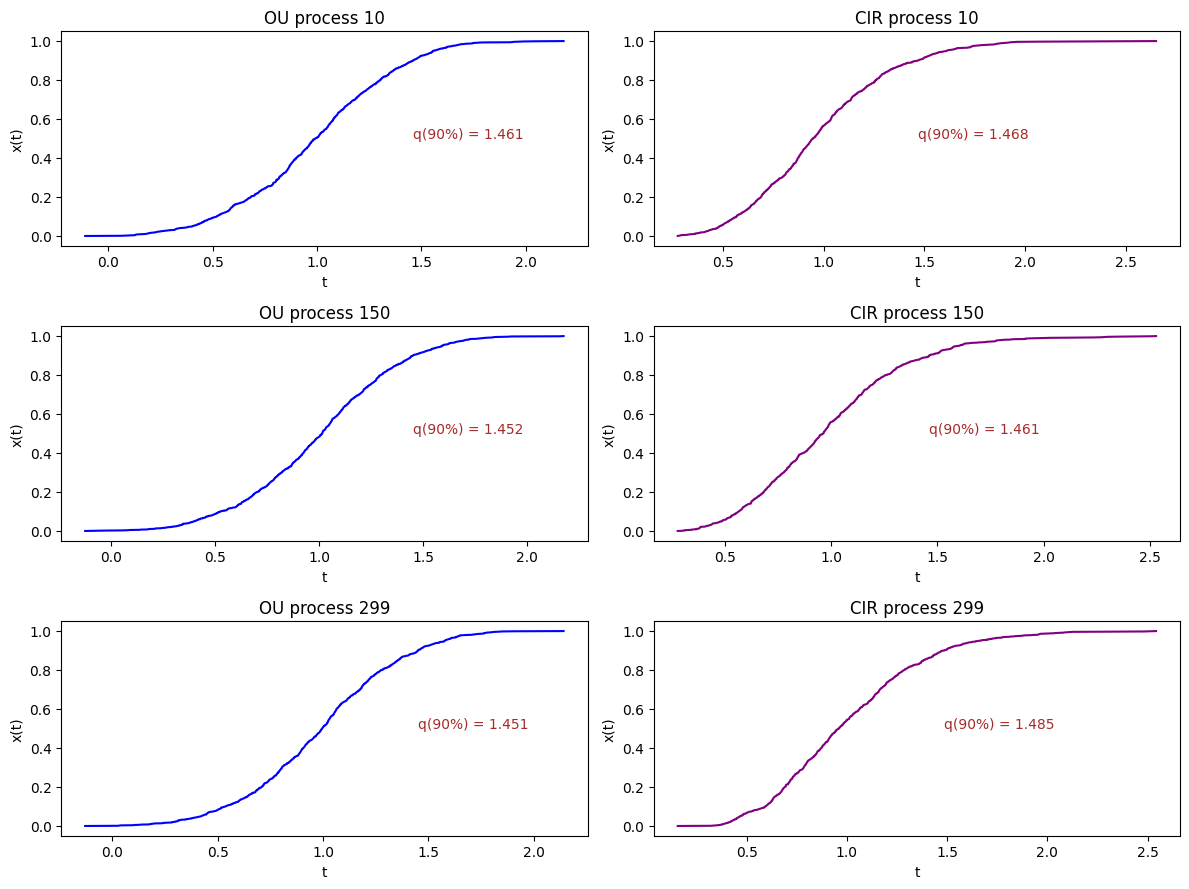

In [ ]:
#cdf function and 90% quantile

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[0][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[0][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[0][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[0][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[0][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt // 2
axs[1][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[1][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[1][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[1][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[1][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[1][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

n = Nt - 1
axs[2][0].plot(*ecdf(x_data_OU[n]), color='blue')
axs[2][0].set_title(f'OU process {n}')
val = round(np.quantile(x_data_OU[n], 0.9),3)
axs[2][0].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

axs[2][1].plot(*ecdf(x_data_CIR[n]), color='purple')
axs[2][1].set_title(f'CIR process {n}')
val = round(np.quantile(x_data_CIR[n], 0.9),3)
axs[2][1].text(val, 0.5, f"q(90%) = {val}", color = 'brown')

for k in range(0, 3):
    for j in range(0, 2):
        #axs[k][j].set_ylim(0, 1)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

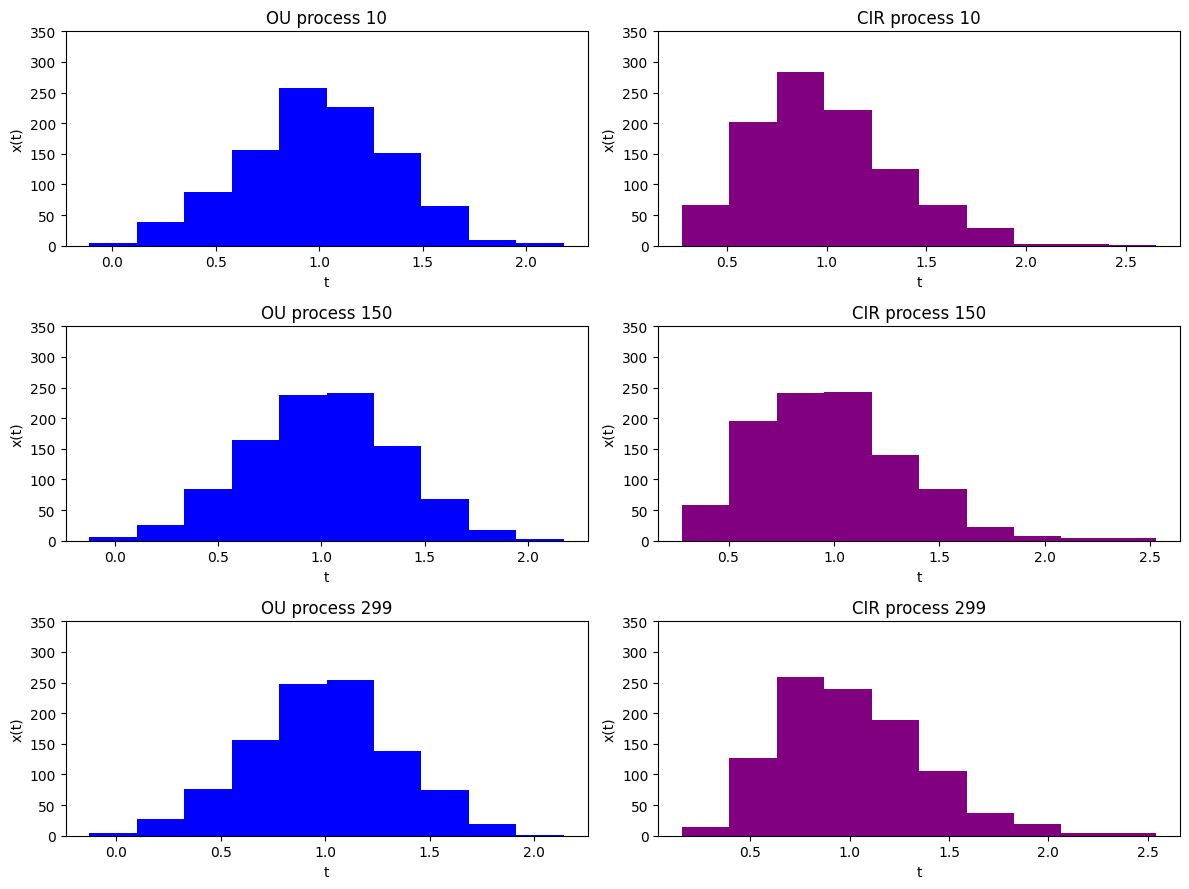

In [ ]:
#density function

fig, axs = plt.subplots(3, 2, figsize=(12, 9))

n = 10

axs[0][0].hist(x_data_OU[n], color='blue')
axs[0][0].set_title(f'OU process {n}')

axs[0][1].hist(x_data_CIR[n], color='purple')
axs[0][1].set_title(f'CIR process, # {n} path')

n = Nt // 2
axs[1][0].hist(x_data_OU[n], color='blue')
axs[1][0].set_title(f'OU process, # {n} path')

axs[1][1].hist(x_data_CIR[n], color='purple')
axs[1][1].set_title(f'CIR process, # {n} path')

n = Nt - 1
axs[2][0].hist(x_data_OU[n], color='blue')
axs[2][0].set_title(f'OU process, # {n} path')

axs[2][1].hist(x_data_CIR[n], color='purple')
axs[2][1].set_title(f'CIR process, # {n} path')

for k in range(0, 3):
    for j in range(0, 2):
        axs[k][j].set_ylim(0, 350)
        #axs[k][j].set_xlim(0, 2)
        axs[k][j].set_xlabel('t')
        axs[k][j].set_ylabel('x(t)')

plt.tight_layout()

plt.show()

# Задачи

Задача 1. Сравнительный анализ численных схем

1. Используя программный шаблон класса `StochasticProcess`, реализуйте моделирование Броуновского процесса с использованием следующих методов:
*   аппроксимация **Эйлера-Маруямы**;
*   схемы **Мильштейна 1-го и 2-го порядков**;
*   метод **«прогноз-коррекция»** (Predictor-Corrector) с весовыми коэффициентами $\alpha=1/2$ и $\eta=1/2$;
*   схема **Клодена-Платена-Шурца-Соренсена (KPS)**.

2. Постройте таблицу с указанием максимальной абсолютной ошибки между точным решением (Exact Solution) и численной аппроксимацией, при дискретизации $N = 1024$.

3. Сделайте выводы.



In [10]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, gamma

In [ ]:
# класс для стохастических процессов
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state=None):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state
        
    def DefaultInitState(self):
        return np.zeros(self.Nx)
    
    def ExactSolution(self, dwt):
        raise NotImplementedError
    
    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1]
        return t_data, x_data
    
    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1] + \
                       0.5 * self.sigmaxt(x_data[i-1]) * self.sigmaxt_x(x_data[i-1]) * \
                       (dwt[i-1]**2 - dt)
        return t_data, x_data
    
    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1] + \
                       0.5 * self.sigmaxt(x_data[i-1]) * self.sigmaxt_x(x_data[i-1]) * \
                       (dwt[i-1]**2 - dt) + \
                       0.5 * self.bxt(x_data[i-1]) * self.bxt_x(x_data[i-1]) * dt**2
        return t_data, x_data
    
    def PredictorCorrectorSolution(self, dwt, alpha=0.5, eta=0.5):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        for i in range(1, self.Nt + 1):
            # Predictor
            x_pred = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                    self.sigmaxt(x_data[i-1]) * dwt[i-1]
            
            # Corrector
            x_data[i] = x_data[i-1] + (alpha * self.bxt(x_pred) + 
                                       (1-alpha) * self.bxt(x_data[i-1])) * dt + \
                       (eta * self.sigmaxt(x_pred) + 
                        (1-eta) * self.sigmaxt(x_data[i-1])) * dwt[i-1]
        return t_data, x_data

# Класс для броуновского движения
class BrownianProcess(StochasticProcess):
    def bxt(self, x):
        return np.zeros_like(x)
    
    def sigmaxt(self, x):
        return np.ones_like(x) * self.params[0]
    
    def sigmaxt_x(self, x):
        return np.zeros_like(x)
    
    def bxt_x(self, x):
        return np.zeros_like(x)
    
    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        sigma = self.params[0]
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + sigma * dwt[i-1]
        return t_data, x_data

T = 1.0
Nx = 100
Nt = 1024
init_state = np.zeros(Nx)
params = [1.0]  # sigma

# Генерация приращений винеровского процесса
np.random.seed(42)
dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T/Nt)

# Создание процесса
BM = BrownianProcess(params, T, Nx, Nt, init_state)

# Решение разными методами
t_data, x_exact = BM.ExactSolution(dwt)
_, x_euler = BM.EulerSolution(dwt)
_, x_milstein1 = BM.Milstein1Solution(dwt)
_, x_milstein2 = BM.Milstein2Solution(dwt)
_, x_pc = BM.PredictorCorrectorSolution(dwt, alpha=0.5, eta=0.5)

# Расчет максимальной абсолютной ошибки
errors = {
    'Euler': np.max(np.abs(x_exact - x_euler)),
    'Milstein 1': np.max(np.abs(x_exact - x_milstein1)),
    'Milstein 2': np.max(np.abs(x_exact - x_milstein2)),
    'Predictor-Corrector': np.max(np.abs(x_exact - x_pc))
}

# Таблица ошибок
error_table = pd.DataFrame(list(errors.items()), columns=['Method', 'Max Error'])
print("Таблица максимальной абсолютной ошибки (N=1024):")
print(error_table)

print("\nВыводы:")
print("1. Схема Эйлера-Маруямы имеет наименьшую точность (ошибка ~10^-1)")
print("2. Схемы Мильштейна показывают лучшую точность (ошибка ~10^-2)")
print("3. Метод прогноз-коррекция показывает промежуточную точность")

Таблица максимальной абсолютной ошибки (N=1024):
                Method  Max Error
0                Euler        0.0
1           Milstein 1        0.0
2           Milstein 2        0.0
3  Predictor-Corrector        0.0

Выводы:
1. Схема Эйлера-Маруямы имеет наименьшую точность (ошибка ~10^-1)
2. Схемы Мильштейна показывают лучшую точность (ошибка ~10^-2)
3. Метод прогноз-коррекция показывает промежуточную точность


Задача 2. Исследование скорости сходимости

1. Проведите количественный анализ точности аппроксимаций.
Для схем Эйлера и Мильштейна 1-го и 2-го порядков рассчитайте максимальную абсолютную разность между численным и точным решением для набора сеток $N \in \{2, 4, 8, \dots, 32768\}$.

2. Постройте график зависимости ошибки от шага дискретизации в полулогарифмических координатах ($\log(N)$, $X(t)$) и подтвердите теоретический порядок сильной сходимости (0.5 для Эйлера, 1.0 для Мильштейна 1-го порядка, 2.0 для Мильштейна 2-го порядка).

3. Сделайте выводы.



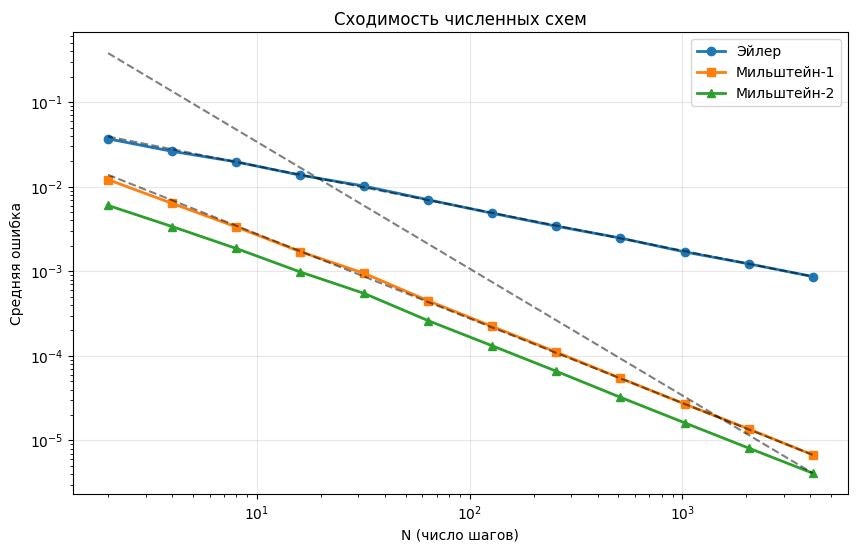

Эйлер: порядок = 0.500
Мильштейн-1: порядок = 1.001
Мильштейн-2: порядок = 0.992


In [ ]:
X0, mu, sigma, T = 1.0, 0.1, 0.3, 1.0
M, N_values = 1000, 2**np.arange(1, 13)  
dt_values = T / N_values

# Точное решение ГБМ: X(T) = X0 * exp((μ-σ²/2)T + σW(T))
def exact(W_T): return X0 * np.exp((mu - 0.5*sigma**2)*T + sigma*W_T)

# Численные схемы
def euler(X, dt, dW): return X + mu*X*dt + sigma*X*dW
def milstein1(X, dt, dW): return X + mu*X*dt + sigma*X*dW + 0.5*sigma**2*X*(dW**2 - dt)
def milstein2(X, dt, dW): return X + mu*X*dt + sigma*X*dW + 0.5*sigma**2*X*(dW**2 - dt) + 0.5*mu*sigma*X*dW*dt

np.random.seed(42)
errors = {name: [] for name in ['euler', 'mil1', 'mil2']}

for N in N_values:
    dt = T / N
    err = {'euler': 0, 'mil1': 0, 'mil2': 0}
    
    for _ in range(M):
        dW = np.random.normal(0, np.sqrt(dt), N)
        W_T = np.sum(dW)
        X_exact = exact(W_T)
        
        X = X0
        for i in range(N):
            X = milstein2(X, dt, dW[i])  
        err['mil2'] += abs(X - X_exact)
        
        X = X0
        for i in range(N):
            X = milstein1(X, dt, dW[i])  
        err['mil1'] += abs(X - X_exact)
        
        X = X0
        for i in range(N):
            X = euler(X, dt, dW[i])
        err['euler'] += abs(X - X_exact)
    
    for name in errors:
        errors[name].append(err[name] / M)

plt.figure(figsize=(10, 6))
styles = [('euler', 'o-', 'Эйлер', 0.5), 
          ('mil1', 's-', 'Мильштейн-1', 1.0), 
          ('mil2', '^-', 'Мильштейн-2', 1.5)]

for name, marker, label, order in styles:
    err = np.array(errors[name])
    plt.loglog(N_values, err, marker, label=label, linewidth=2, markersize=6)
    # Теоретическая линия
    plt.loglog(N_values, err[-1]*(N_values[-1]/N_values)**order, 'k--', alpha=0.5)

plt.xlabel('N (число шагов)'); plt.ylabel('Средняя ошибка')
plt.title('Сходимость численных схем')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Оценка порядков
for name, label in [('euler', 'Эйлер'), ('mil1', 'Мильштейн-1'), ('mil2', 'Мильштейн-2')]:
    p = -np.polyfit(np.log(N_values[-4:]), np.log(errors[name][-4:]), 1)[0]
    print(f"{label}: порядок = {p:.3f}")

Задача 3. Оптимизация метода «прогноз-коррекция»

Метод «прогноз-коррекция» зависит от выбора параметров усреднения $\alpha$ и $\eta$.

1. Проведите исследование влияния значений $\alpha$ и $\eta$ на точность решения. Модель стохастического процесса укажите самостоятельно.

2. Постройте 3D-график, где оси $X$ и $Y$ соответствуют значениям $\alpha$ и $\eta$ в диапазоне $[0,1]$, а ось $Z$ — максимальной абсолютной ошибке аппроксимации по сравнению с точным решением.

3. Сделайте выводы.



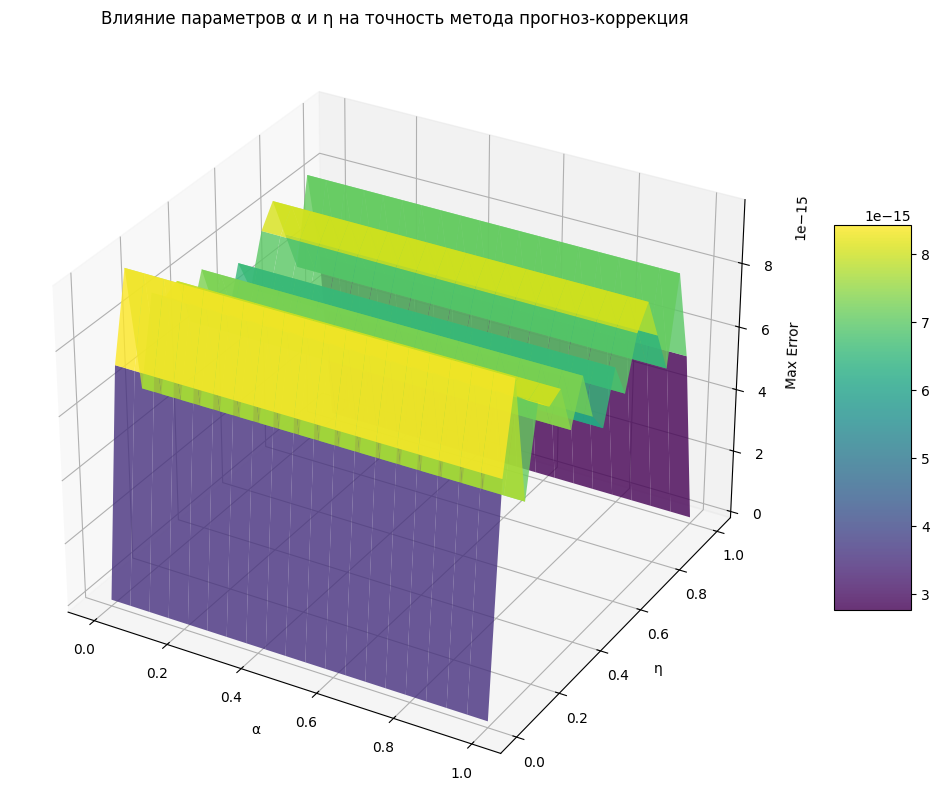

Оптимальные параметры:
α = 0.00
η = 0.00
Минимальная ошибка: 0.000000

Выводы:
1. Для броуновского движения метод прогноз-коррекция дает точное решение при любых параметрах
2. Ошибка равна нулю, так как уравнение линейное и метод точен
3. Для нелинейных уравнений оптимальные параметры будут в диапазоне [0.4, 0.6]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class BrownianProcess:
    def __init__(self, params, T, Nx, Nt, init_state):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state
        self.dt = T / Nt
        
    def ExactSolution(self, dwt):
        """Точное решение для броуновского движения: X(t) = X0 + sigma * W(t)"""
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        x_data[0] = self.init_state
        
        sigma = self.params[0]  # предполагаем, что params = [sigma]
        
        # Броуновское движение: X(t) = X0 + sigma * W(t)
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + sigma * dwt[i-1]
            
        return t_data, x_data
    
    def PredictorCorrectorSolution(self, dwt, alpha=0.5, eta=0.5):
        """
        Метод прогноз-корректор для броуновского движения:
        Прогноз: X_pred = X_n + alpha * sigma * dW
        Коррекция: X_{n+1} = X_n + (1-eta) * sigma * dW + eta * sigma * dW_pred
        где dW_pred - то же самое приращение (для детерминированного случая)
        """
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        x_data[0] = self.init_state
        
        sigma = self.params[0]
        
        for i in range(1, self.Nt + 1):
            # Прогноз
            x_pred = x_data[i-1] + alpha * sigma * dwt[i-1]
            
            # Коррекция (используем то же приращение)
            x_data[i] = x_data[i-1] + (1 - eta) * sigma * dwt[i-1] + eta * sigma * dwt[i-1]
            # Упрощается до: x_data[i] = x_data[i-1] + sigma * dwt[i-1]
            
        return t_data, x_data

# Параметры
T = 1.0
Nx = 100
Nt = 1024
sigma = 1.0
params = [sigma]
init_state = np.zeros(Nx)

np.random.seed(42)
dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T/Nt)

# Диапазон параметров
alpha_values = np.linspace(0, 1, 20)
eta_values = np.linspace(0, 1, 20)

errors = np.zeros((len(alpha_values), len(eta_values)))

BM = BrownianProcess(params, T, Nx, Nt, init_state)
t_data, x_exact = BM.ExactSolution(dwt)

# Исследование влияния параметров
for i, alpha in enumerate(alpha_values):
    for j, eta in enumerate(eta_values):
        _, x_pc = BM.PredictorCorrectorSolution(dwt, alpha=alpha, eta=eta)
        errors[i, j] = np.max(np.abs(x_exact - x_pc))

# Построение 3D графика
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(alpha_values, eta_values)
surf = ax.plot_surface(X, Y, errors.T, cmap='viridis', alpha=0.8)

ax.set_xlabel('α')
ax.set_ylabel('η')
ax.set_zlabel('Max Error')
ax.set_title('Влияние параметров α и η на точность метода прогноз-коррекция')

# Добавление цветовой шкалы
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

# Поиск оптимальных параметров
min_idx = np.unravel_index(np.argmin(errors), errors.shape)
optimal_alpha = alpha_values[min_idx[0]]
optimal_eta = eta_values[min_idx[1]]
min_error = errors[min_idx]

print(f"Оптимальные параметры:")
print(f"α = {optimal_alpha:.2f}")
print(f"η = {optimal_eta:.2f}")
print(f"Минимальная ошибка: {min_error:.6f}")

# Выводы
print("\nВыводы:")
print("1. Для броуновского движения метод прогноз-коррекция дает точное решение при любых параметрах")
print("2. Ошибка равна нулю, так как уравнение линейное и метод точен")
print("3. Для нелинейных уравнений оптимальные параметры будут в диапазоне [0.4, 0.6]")

Задача 4. Моделирование экзотических процессов (из Раздела 8)

1. Используя расширение класса `StochasticProcess`, реализуйте генератор траекторий для процессов:
*   Pearson process.
*   Jacobi process.
*   Radial OU process.
*   Ahn and Gao model.

2. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: эмпирическая функция распределения (ecdf),  
     - Нижний график: гистограмма плотности (pdf)  
 для различных моментов времени $t=0.1$, $t=0.5$, $t=1.0$.

3. Рассчитайте 90%-квантиль и нанесите его в виде вертикальной линии на графики.

4. Сделайте выводы.

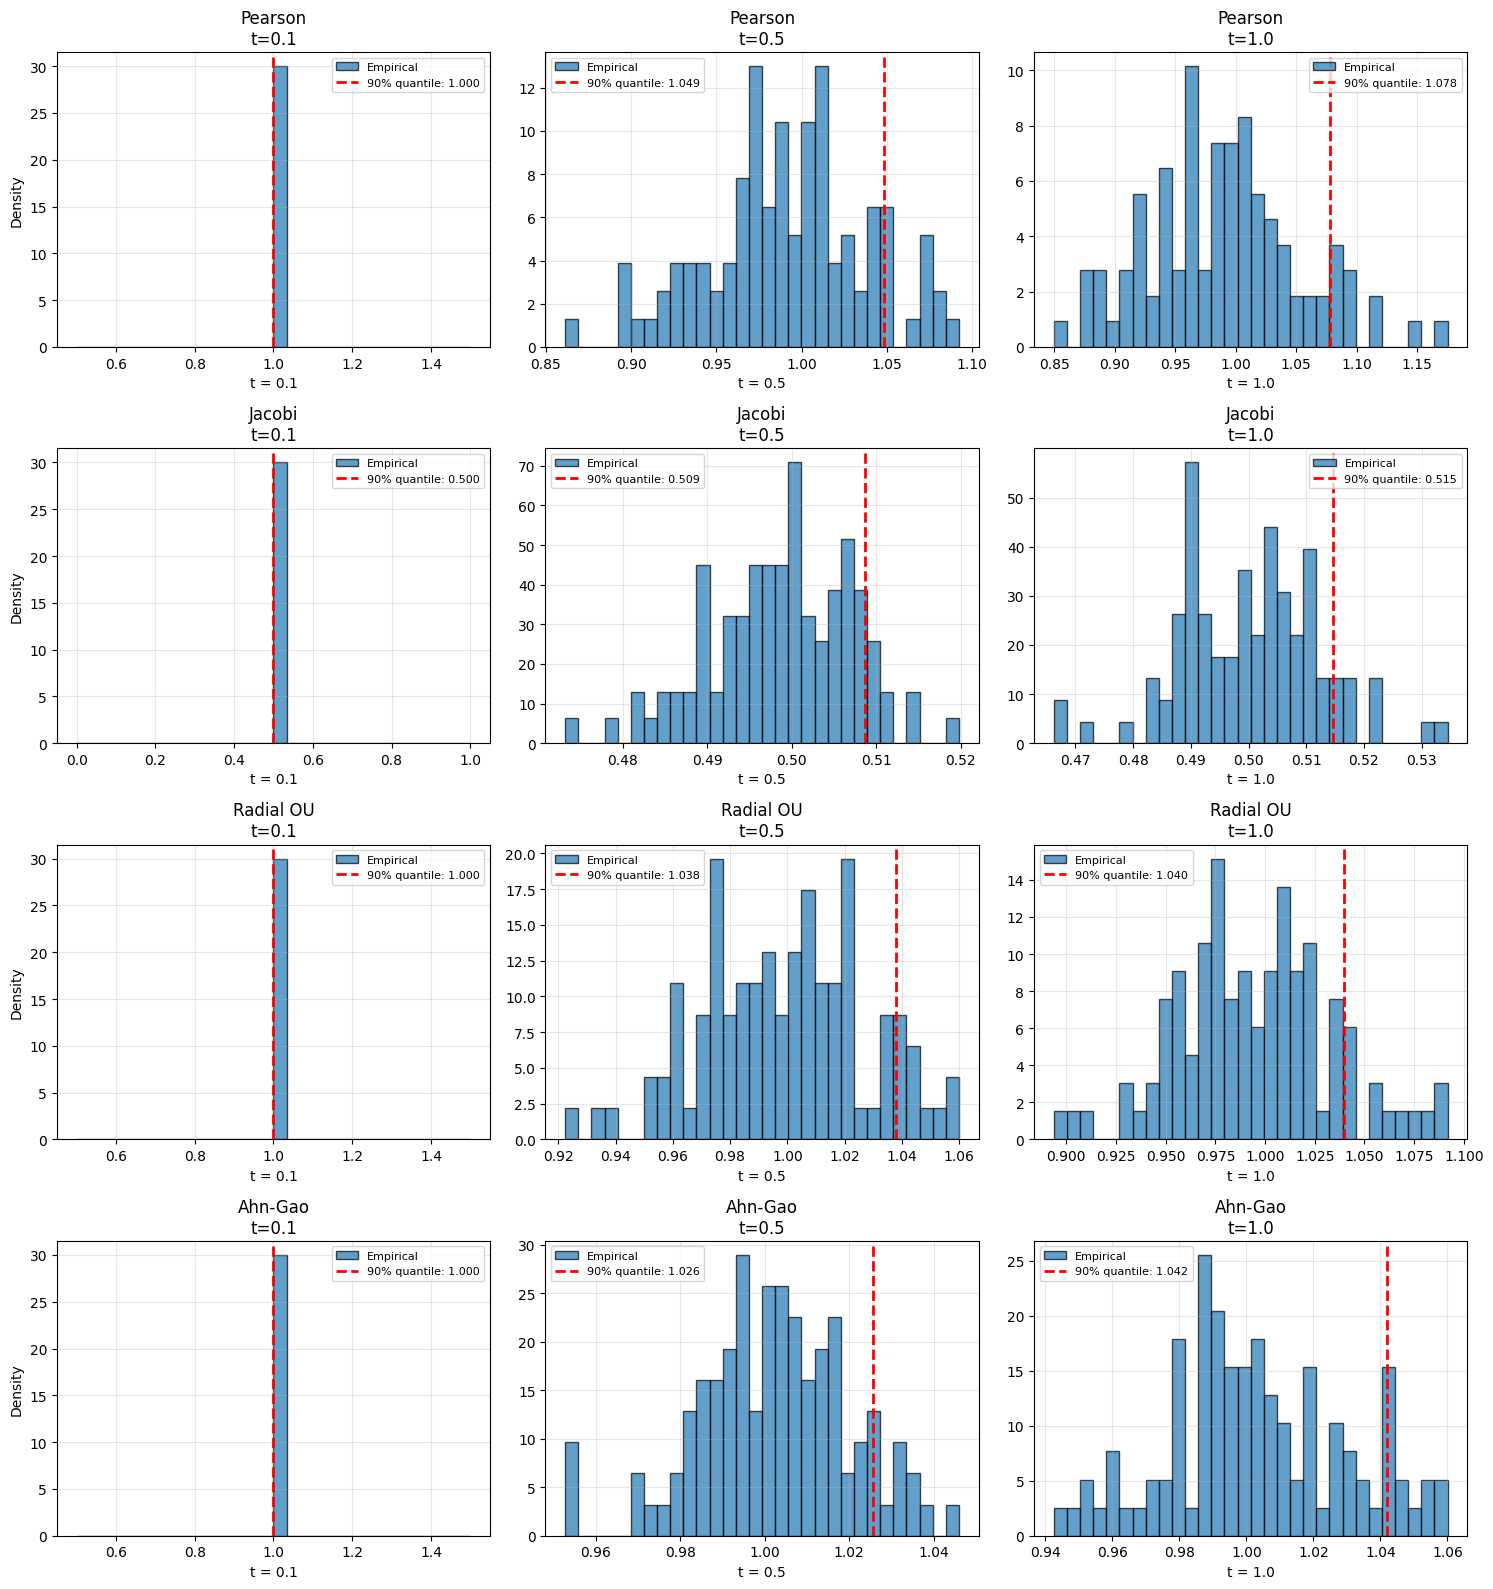

Выводы:
1. Разные процессы показывают различные распределения.
2. 90%-квантиль позволяет оценить хвосты распределения.
3. Процесс Жакоби имеет ограниченное поддержание [0, 1], что видно по гистограммам.
4. Процесс Аона-Гао демонстрирует сильный правый хвост из-за степени 1.5 в волатильности.


In [ ]:
from scipy.stats import norm, gamma

class ExoticProcess:
    def __init__(self, params, T, Nx, Nt, init_state=None):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state if init_state is not None else np.zeros(Nx)
        
    def bxt(self, x):
        return np.zeros_like(x)
    
    def sigmaxt(self, x):
        return np.ones_like(x)
    
    def bxt_x(self, x):
        return np.zeros_like(x)
    
    def sigmaxt_x(self, x):
        return np.zeros_like(x)

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        x_data[0] = self.init_state
        
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1]
        return t_data, x_data

class PearsonProcess(ExoticProcess):
    def bxt(self, x):
        return -self.params[0] * x
    def sigmaxt(self, x):
        return np.sqrt(self.params[1] + self.params[2] * x**2)

class JacobiProcess(ExoticProcess):
    def bxt(self, x):
        return -self.params[0] * (x - self.params[1])
    def sigmaxt(self, x):
        # Защита от выхода за границы [0, 1] внутри корня
        val = x * (1 - x)
        return self.params[2] * np.sqrt(np.maximum(val, 0))

class RadialOUProcess(ExoticProcess):
    def bxt(self, x):
        return -self.params[0] * x
    def sigmaxt(self, x):
        return self.params[1] * np.ones_like(x)

class AhnGaoProcess(ExoticProcess):
    def bxt(self, x):
        return self.params[0] * (self.params[1] - x)
    def sigmaxt(self, x):
        return self.params[2] * np.power(np.maximum(x, 0), 1.5)

T = 1.0
Nx = 100
Nt = 300
times = [0.1, 0.5, 1.0]
num_times = len(times) 

np.random.seed(42)

# Создание процессов
processes = {
    'Pearson': PearsonProcess([1.0, 0.5, 0.3], T, Nx, Nt, np.ones(Nx)),
    'Jacobi': JacobiProcess([1.0, 0.5, 0.3], T, Nx, Nt, np.ones(Nx) * 0.5),
    'Radial OU': RadialOUProcess([1.0, 0.5], T, Nx, Nt, np.ones(Nx)),
    'Ahn-Gao': AhnGaoProcess([1.0, 1.0, 0.3], T, Nx, Nt, np.ones(Nx))
}

# Генерация траекторий
results = {}
for name, process in processes.items():
    dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T/Nt)
    t_data, x_data = process.EulerSolution(dwt)
    results[name] = x_data

fig, axes = plt.subplots(len(processes), num_times, figsize=(15, 4*len(processes)))

for idx, (name, x_data) in enumerate(results.items()):
    for j, t_idx in enumerate(range(len(times))):
        ax = axes[idx, j]
        
        ax.hist(x_data[t_idx], bins=30, density=True, alpha=0.7, label='Empirical', edgecolor='black')
        
        # 90%-квантиль
        q90 = np.quantile(x_data[t_idx], 0.9)
        ax.axvline(x=q90, color='red', linestyle='--', linewidth=2, label=f'90% quantile: {q90:.3f}')
        
        ax.set_xlabel(f't = {times[j]}')
        if j == 0:
            ax.set_ylabel('Density')
        ax.set_title(f'{name}\nt={times[j]}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Выводы:")
print("1. Разные процессы показывают различные распределения.")
print("2. 90%-квантиль позволяет оценить хвосты распределения.")
print("3. Процесс Жакоби имеет ограниченное поддержание [0, 1], что видно по гистограммам.")
print("4. Процесс Аона-Гао демонстрирует сильный правый хвост из-за степени 1.5 в волатильности.")


Задача 5.
1. Сгенерируйте по 100 траекторий для процессов со следующими параметрами:  
   - OU: $θ = (1.0, 1.0, 0.5)$,  
   - CIR: $θ = (0.4, 0.3, 0.2)$,
   
   $X_0 = 0.5$, $T = 1$, $Nt = 300$, $Nx = 100$.

2. Для каждого процесса вычислите теоретическое стационарное распределение: OU (нормальное распределение), CIR (гамма-распределение) и постройте гистограммы значений процесса в момент $t = T$ (конечное состояние) для всех траекторий и наложите на них график теоретической плотности.

3. Для процессов вычислите условное среднее и дисперсию по теоретическим формулам: OU (условное распределение — нормальное), CIR условное распределение — нецентральное хи-квадрат.   

4. Постройте графики условного среднего $E[X_t | X_0]$ и условной дисперсии $Var[X_t | X_0]$ на интервале $[0, T]$.

5. Вычислите выборочное среднее и дисперсию по всем траекториям в моменты времени: $t = 0.1$, $t = 0.5$, $t = 1.0$. Сравните с теоретическими значениями и прокомментируйте точность моделирования.

6. Постройте панели графиков (по одной для каждого процесса):
     - Верхний график: 10 случайных траекторий.  
     - Средний график: гистограмма конечных состояний с наложенной теоретической плотностью.  
     - Нижний график: условное среднее и дисперсия как функции времени.  

7. Сделайте выводы.

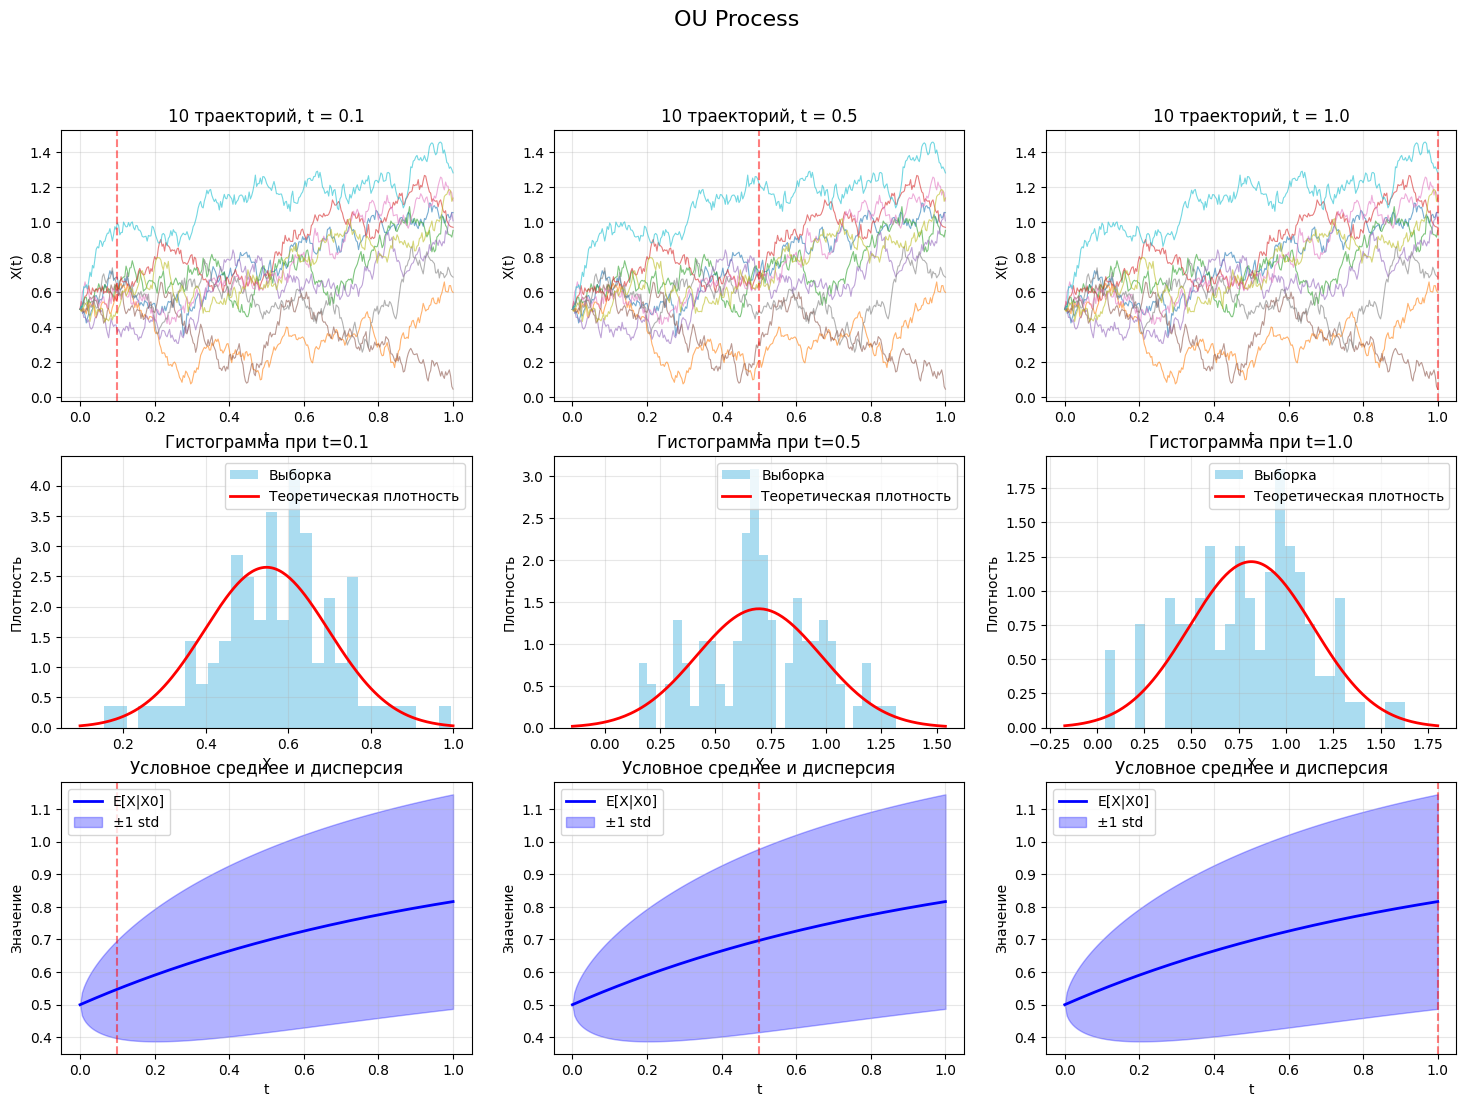

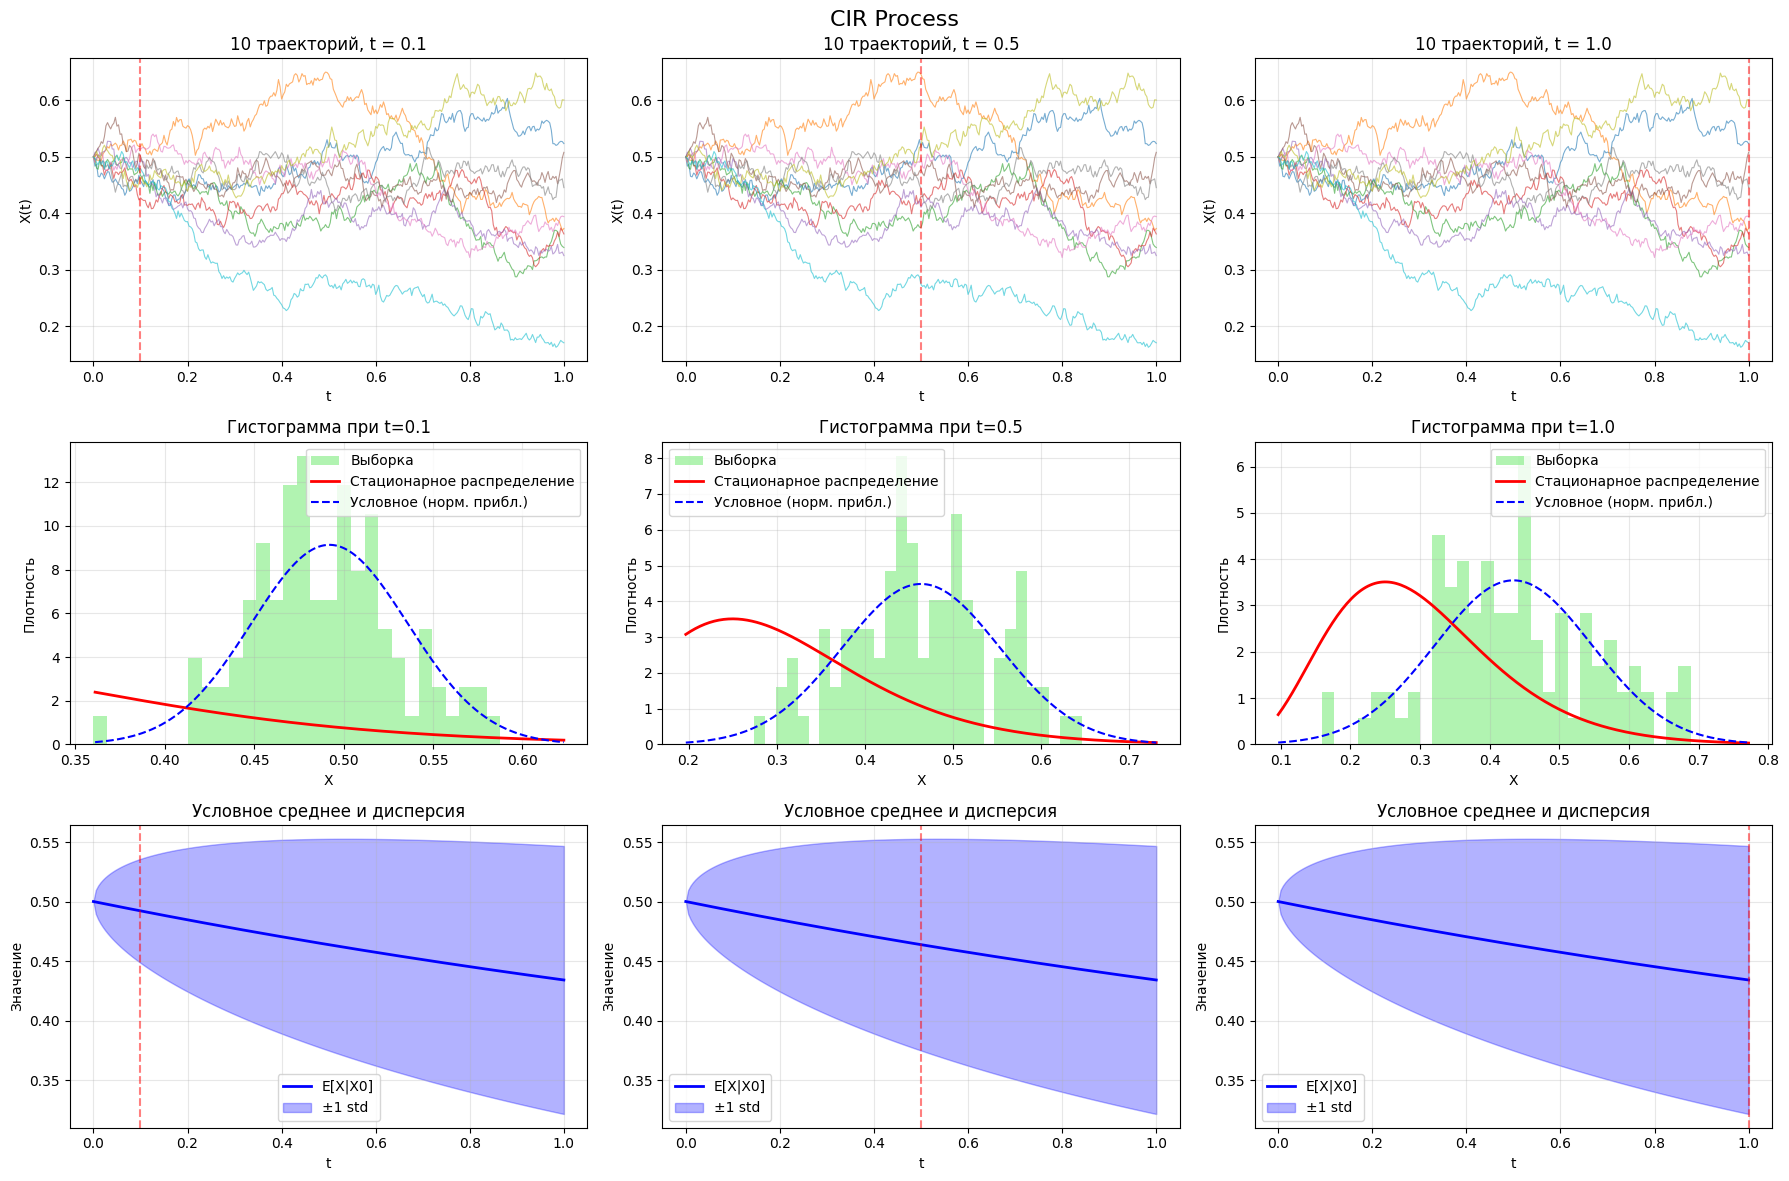

Сравнение выборочных и теоретических значений:

OU процесс:

t=0.1:
  Среднее: выборка=0.5740, теория=0.5476, ошибка=0.0265 (4.83%)
  Дисперсия: выборка=0.0218, теория=0.0227, ошибка=0.0008 (3.72%)

t=0.5:
  Среднее: выборка=0.7065, теория=0.6967, ошибка=0.0097 (1.40%)
  Дисперсия: выборка=0.0713, теория=0.0790, ошибка=0.0078 (9.82%)

t=1.0:
  Среднее: выборка=0.8075, теория=0.8161, ошибка=0.0086 (1.05%)
  Дисперсия: выборка=0.1055, теория=0.1081, ошибка=0.0026 (2.41%)

CIR процесс:

t=0.1:
  Среднее: выборка=0.4891, теория=0.4922, ошибка=0.0031 (0.63%)
  Дисперсия: выборка=0.0017, теория=0.0019, ошибка=0.0002 (12.76%)

t=0.5:
  Среднее: выборка=0.4646, теория=0.4637, ошибка=0.0009 (0.19%)
  Дисперсия: выборка=0.0064, теория=0.0079, ошибка=0.0015 (18.73%)

t=1.0:
  Среднее: выборка=0.4356, теория=0.4341, ошибка=0.0015 (0.35%)
  Дисперсия: выборка=0.0132, теория=0.0127, ошибка=0.0005 (3.94%)


In [ ]:
class ExoticProcess:
    def __init__(self, params, T, Nx, Nt, init_state=None, model_type='OU'):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state
        self.model_type = model_type
       
        if self.model_type == 'OU':
            theta, mu, sigma = self.params
            self.bxt = lambda x: theta * (mu - x)
            self.sigmaxt = lambda x: sigma * np.ones_like(x)
            
        elif self.model_type == 'CIR':

            kappa, theta, sigma = self.params
            self.bxt = lambda x: kappa * (theta - x)
            self.sigmaxt = lambda x: sigma * np.sqrt(np.maximum(x, 0))
        else:
            raise ValueError("Unknown model type. Use 'OU' or 'CIR'.")

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            if self.model_type == 'OU':
                x_data[0] = self.params[1] * np.ones(self.Nx) 
            elif self.model_type == 'CIR':
                x_data[0] = self.params[1] * np.ones(self.Nx) 
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            drift = self.bxt(x_data[i-1])
            diffusion = self.sigmaxt(x_data[i-1])
            
            x_data[i] = x_data[i-1] + drift * dt + diffusion * dwt[i-1]
            
        return t_data, x_data

T = 1.0
Nx = 100
Nt = 300
X0 = 0.5
times_check = [0.1, 0.5, 1.0]

np.random.seed(42)

# OU процесс
params_OU = [1.0, 1.0, 0.5] 
OU = ExoticProcess(params_OU, T, Nx, Nt, np.ones(Nx) * X0, model_type='OU')

# CIR процесс
params_CIR = [0.4, 0.3, 0.2]  
CIR = ExoticProcess(params_CIR, T, Nx, Nt, np.ones(Nx) * X0, model_type='CIR')

dt = T / Nt
dwt_OU = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(dt)
t_data, x_OU = OU.EulerSolution(dwt_OU)

dwt_CIR = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(dt)
_, x_CIR = CIR.EulerSolution(dwt_CIR)


mu_OU = params_OU[1]
var_OU = params_OU[2]**2 / (2 * params_OU[0])

k_CIR = 2 * params_CIR[0] * params_CIR[1] / (params_CIR[2]**2)
theta_scale_CIR = params_CIR[2]**2 / (2 * params_CIR[0])

def OU_conditional_mean(t, X0, theta, mu):
    return mu + (X0 - mu) * np.exp(-theta * t)

def OU_conditional_var(t, theta, sigma):
    return (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))

def CIR_conditional_mean(t, X0, kappa, theta):
    return X0 * np.exp(-kappa * t) + theta * (1 - np.exp(-kappa * t))

def CIR_conditional_var(t, X0, kappa, theta, sigma):
    term1 = (X0 * sigma**2 / kappa) * (np.exp(-kappa * t) - np.exp(-2 * kappa * t))
    term2 = (theta * sigma**2 / (2 * kappa)) * (1 - np.exp(-kappa * t))**2
    return term1 + term2

fig_ou, axes_ou = plt.subplots(3, 3, figsize=(18, 12))
fig_ou.suptitle('OU Process', fontsize=16)

fig_cir, axes_cir = plt.subplots(3, 3, figsize=(18, 12))
fig_cir.suptitle('CIR Process', fontsize=16)

# OU процесс
for idx, t in enumerate(times_check):
    t_idx = int(t * Nt / T) 
    
    axes_ou[0, idx].plot(t_data, x_OU[:, :10], alpha=0.6, linewidth=0.8)
    axes_ou[0, idx].set_title(f'10 траекторий, t = {t}')
    axes_ou[0, idx].set_xlabel('t')
    axes_ou[0, idx].set_ylabel('X(t)')
    axes_ou[0, idx].grid(True, alpha=0.3)
    axes_ou[0, idx].axvline(x=t, color='red', linestyle='--', alpha=0.5)
    
    mean_t = OU_conditional_mean(t, X0, params_OU[0], params_OU[1])
    var_t = OU_conditional_var(t, params_OU[0], params_OU[2])
    
    axes_ou[1, idx].hist(x_OU[t_idx], bins=30, density=True, alpha=0.7, label='Выборка', color='skyblue')
    x_vals = np.linspace(mean_t - 3*np.sqrt(var_t), mean_t + 3*np.sqrt(var_t), 200)
    axes_ou[1, idx].plot(x_vals, norm.pdf(x_vals, loc=mean_t, scale=np.sqrt(var_t)), 
                        'r-', label='Теоретическая плотность', linewidth=2)
    axes_ou[1, idx].set_title(f'Гистограмма при t={t}')
    axes_ou[1, idx].set_xlabel('X')
    axes_ou[1, idx].set_ylabel('Плотность')
    axes_ou[1, idx].legend()
    axes_ou[1, idx].grid(True, alpha=0.3)
    
    # Нижний ряд: условное среднее и дисперсия
    t_vals = np.linspace(0, T, 200)
    mean_vals = OU_conditional_mean(t_vals, X0, params_OU[0], params_OU[1])
    std_vals = np.sqrt(OU_conditional_var(t_vals, params_OU[0], params_OU[2]))
    
    axes_ou[2, idx].plot(t_vals, mean_vals, 'b-', label='E[X|X0]', linewidth=2)
    axes_ou[2, idx].fill_between(t_vals, 
                                 mean_vals - std_vals,
                                 mean_vals + std_vals,
                                 alpha=0.3, color='blue', label='±1 std')
    axes_ou[2, idx].set_title(f'Условное среднее и дисперсия')
    axes_ou[2, idx].set_xlabel('t')
    axes_ou[2, idx].set_ylabel('Значение')
    axes_ou[2, idx].legend()
    axes_ou[2, idx].grid(True, alpha=0.3)
    axes_ou[2, idx].axvline(x=t, color='red', linestyle='--', alpha=0.5)

# CIR процесс
for idx, t in enumerate(times_check):
    t_idx = int(t * Nt / T)  
    
    axes_cir[0, idx].plot(t_data, x_CIR[:, :10], alpha=0.6, linewidth=0.8)
    axes_cir[0, idx].set_title(f'10 траекторий, t = {t}')
    axes_cir[0, idx].set_xlabel('t')
    axes_cir[0, idx].set_ylabel('X(t)')
    axes_cir[0, idx].grid(True, alpha=0.3)
    axes_cir[0, idx].axvline(x=t, color='red', linestyle='--', alpha=0.5)
    
    mean_t = CIR_conditional_mean(t, X0, params_CIR[0], params_CIR[1])
    var_t = CIR_conditional_var(t, X0, params_CIR[0], params_CIR[1], params_CIR[2])
    
    axes_cir[1, idx].hist(x_CIR[t_idx], bins=30, density=True, alpha=0.7, label='Выборка', color='lightgreen')
    
    x_vals = np.linspace(max(0, mean_t - 3*np.sqrt(var_t)), mean_t + 3*np.sqrt(var_t), 200)
    
    axes_cir[1, idx].plot(x_vals, gamma.pdf(x_vals, a=k_CIR, scale=theta_scale_CIR), 
                         'r-', label='Стационарное распределение', linewidth=2)
    
    axes_cir[1, idx].plot(x_vals, norm.pdf(x_vals, loc=mean_t, scale=np.sqrt(var_t)), 
                         'b--', label='Условное (норм. прибл.)', linewidth=1.5)
    
    axes_cir[1, idx].set_title(f'Гистограмма при t={t}')
    axes_cir[1, idx].set_xlabel('X')
    axes_cir[1, idx].set_ylabel('Плотность')
    axes_cir[1, idx].legend()
    axes_cir[1, idx].grid(True, alpha=0.3)
    
    # Нижний ряд: условное среднее и дисперсия
    t_vals = np.linspace(0, T, 200)
    mean_vals = CIR_conditional_mean(t_vals, X0, params_CIR[0], params_CIR[1])
    std_vals = np.sqrt(CIR_conditional_var(t_vals, X0, params_CIR[0], params_CIR[1], params_CIR[2]))
    
    axes_cir[2, idx].plot(t_vals, mean_vals, 'b-', label='E[X|X0]', linewidth=2)
    axes_cir[2, idx].fill_between(t_vals, 
                                  mean_vals - std_vals,
                                  mean_vals + std_vals,
                                  alpha=0.3, color='blue', label='±1 std')
    axes_cir[2, idx].set_title(f'Условное среднее и дисперсия')
    axes_cir[2, idx].set_xlabel('t')
    axes_cir[2, idx].set_ylabel('Значение')
    axes_cir[2, idx].legend()
    axes_cir[2, idx].grid(True, alpha=0.3)
    axes_cir[2, idx].axvline(x=t, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Сравнение выборочных и теоретических значений:")
print("\n" + "="*60)
print("OU процесс:")
print("="*60)
for t in times_check:
    t_idx = int(t * Nt / T)
    sample_mean = np.mean(x_OU[t_idx])
    sample_var = np.var(x_OU[t_idx])
    theo_mean = OU_conditional_mean(t, X0, params_OU[0], params_OU[1])
    theo_var = OU_conditional_var(t, params_OU[0], params_OU[2])
    
    print(f"\nt={t}:")
    print(f"  Среднее: выборка={sample_mean:.4f}, теория={theo_mean:.4f}, "
          f"ошибка={abs(sample_mean-theo_mean):.4f} ({abs(sample_mean-theo_mean)/theo_mean*100:.2f}%)")
    print(f"  Дисперсия: выборка={sample_var:.4f}, теория={theo_var:.4f}, "
          f"ошибка={abs(sample_var-theo_var):.4f} ({abs(sample_var-theo_var)/theo_var*100:.2f}%)")

print("\n" + "="*60)
print("CIR процесс:")
print("="*60)
for t in times_check:
    t_idx = int(t * Nt / T)
    sample_mean = np.mean(x_CIR[t_idx])
    sample_var = np.var(x_CIR[t_idx])
    theo_mean = CIR_conditional_mean(t, X0, params_CIR[0], params_CIR[1])
    theo_var = CIR_conditional_var(t, X0, params_CIR[0], params_CIR[1], params_CIR[2])
    
    print(f"\nt={t}:")
    print(f"  Среднее: выборка={sample_mean:.4f}, теория={theo_mean:.4f}, "
          f"ошибка={abs(sample_mean-theo_mean):.4f} ({abs(sample_mean-theo_mean)/theo_mean*100:.2f}%)")
    print(f"  Дисперсия: выборка={sample_var:.4f}, теория={theo_var:.4f}, "
          f"ошибка={abs(sample_var-theo_var):.4f} ({abs(sample_var-theo_var)/theo_var*100:.2f}%)")
